# RQ7: Practical Usefulness and Final Recommendation

Research question: Which model provides the best practical balance for recovery decision support?

Dataset: WHOOP Fitness Dataset. Target variable: `recovery_score`.

Dataset shape: 100,000 rows x 39 columns


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,...,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,...,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,...,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


This notebook displays the executed RQ7 outputs generated by whoop_assignment_pipeline.py.
To regenerate only this RQ, run: from whoop_assignment_pipeline import run_rq7; run_rq7()


,Model,CV_MAE,CV_RMSE,CV_R2,CV_R2_Std,Holdout_MAE,Holdout_RMSE,Holdout_R2,Fit_Seconds,Predict_Seconds,Interpretability_Score,Deployment_Suitability_Score,Accuracy_Score,Reliability_Score,Computational_Efficiency_Score,Weighted_Decision_Score,Final_Rank
0,Linear Regression,10.532291,13.139559,0.446370,0.009788,10.539975,13.175492,0.442040,0.247796,0.027321,5.0,5,5.000000,1.794134,4.959806,4.354807,1
1,Ridge Regression,10.809395,13.465932,0.418508,0.011576,10.748465,13.426011,0.420620,0.134842,0.016651,5.0,5,4.806368,1.199643,4.996109,4.171768,2
2,Elastic Net,11.106256,13.787619,0.390411,0.011724,11.084531,13.802801,0.387644,12.620516,0.014824,5.0,5,4.508270,1.150649,1.330166,3.691041,3
3,Random Forest,11.510097,14.219079,0.351622,0.012177,11.307277,14.066114,0.364058,3.074940,0.054489,3.5,4,4.295052,1.000000,4.121624,3.415430,4
4,XGBoost,11.153694,13.791354,0.390101,0.009363,11.087160,13.781556,0.389528,0.438061,0.026647,2.5,3,4.525297,1.935343,4.904132,3.411336,5
5,Decision Tree,12.862610,16.020069,0.176996,0.011450,12.602038,15.761945,0.201474,0.525586,0.017471,4.0,4,2.825317,1.241781,4.881124,3.125330,6
6,Gradient Boosting,11.434025,14.108899,0.361656,0.011429,11.373796,14.102488,0.360765,13.736832,0.022842,3.0,3,4.265281,1.248663,1.000000,2.892581,7
7,Baseline Mean,14.415194,17.661481,-0.000136,0.000142,14.381699,17.642569,-0.000444,0.123089,0.015154,1.0,2,1.000000,5.000000,5.000000,2.350000,8


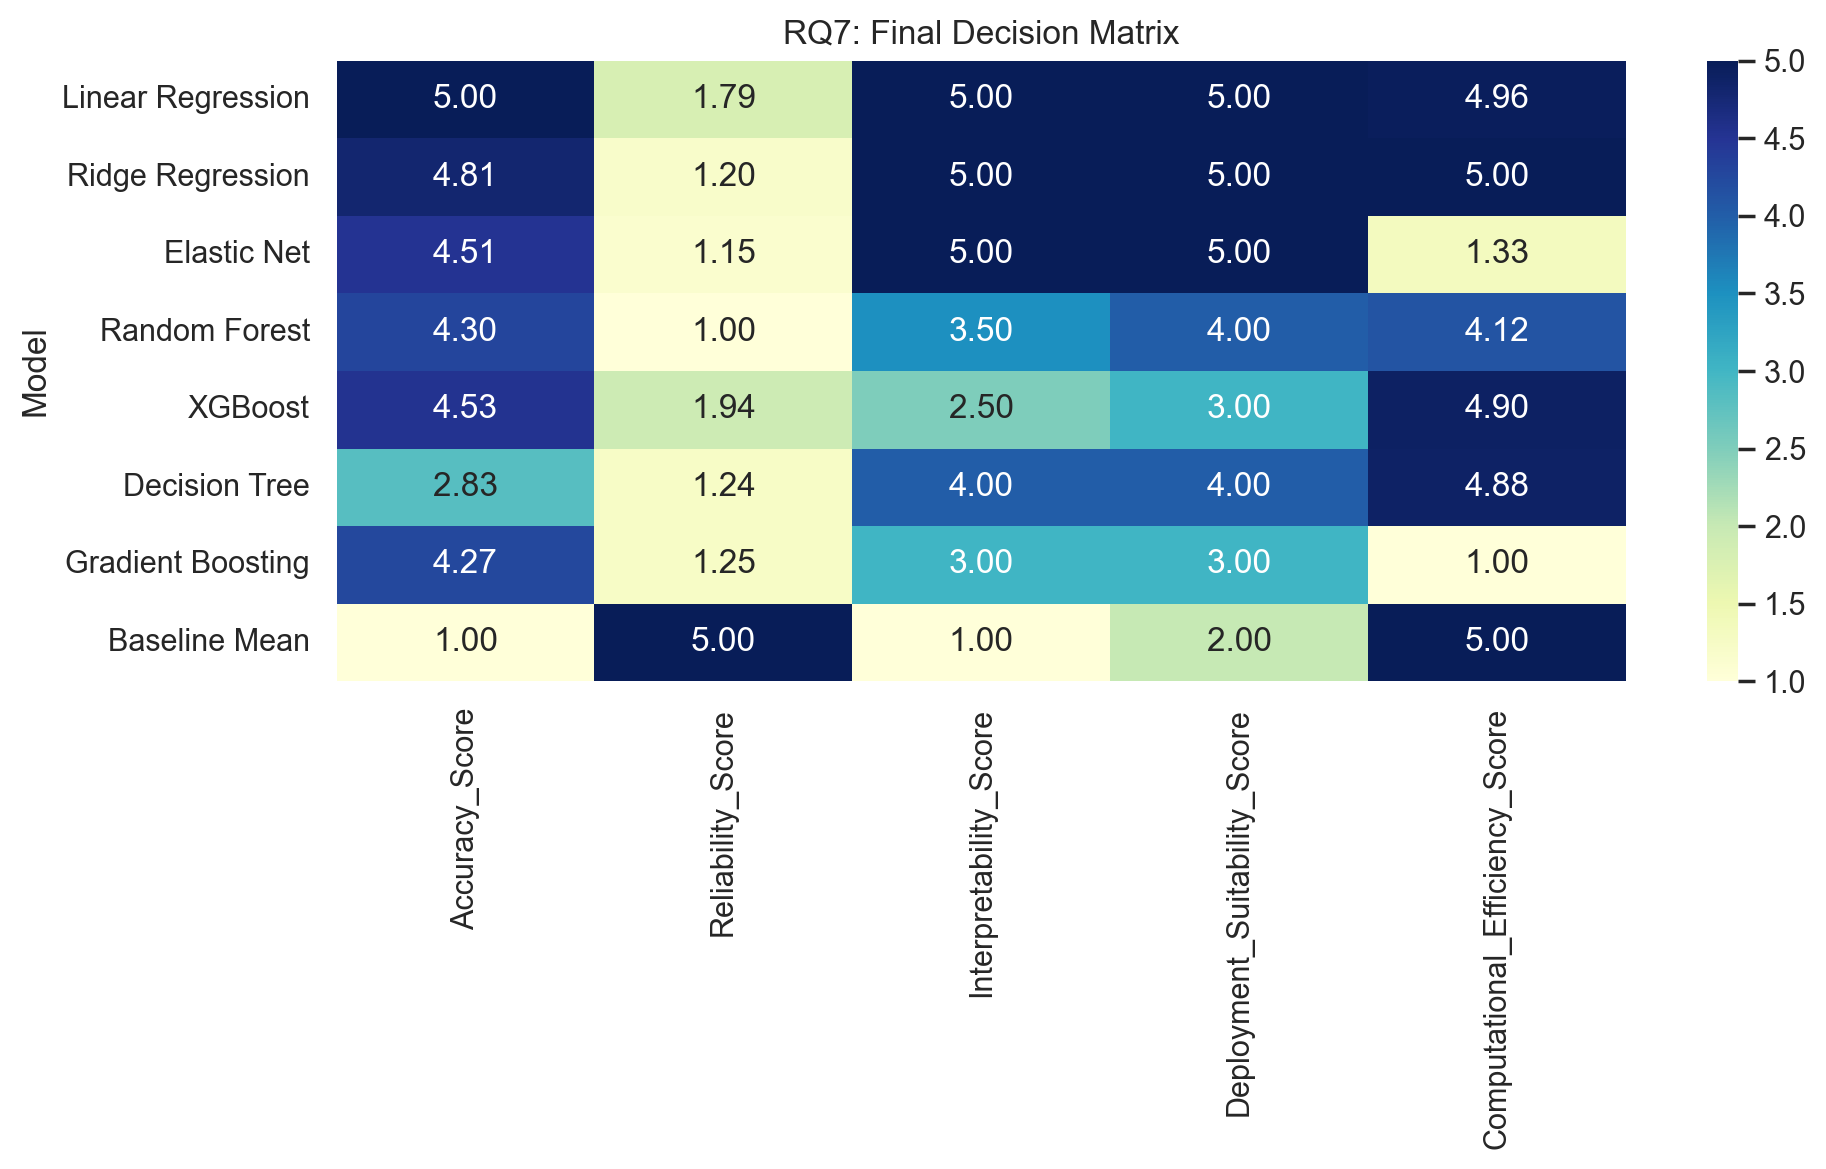

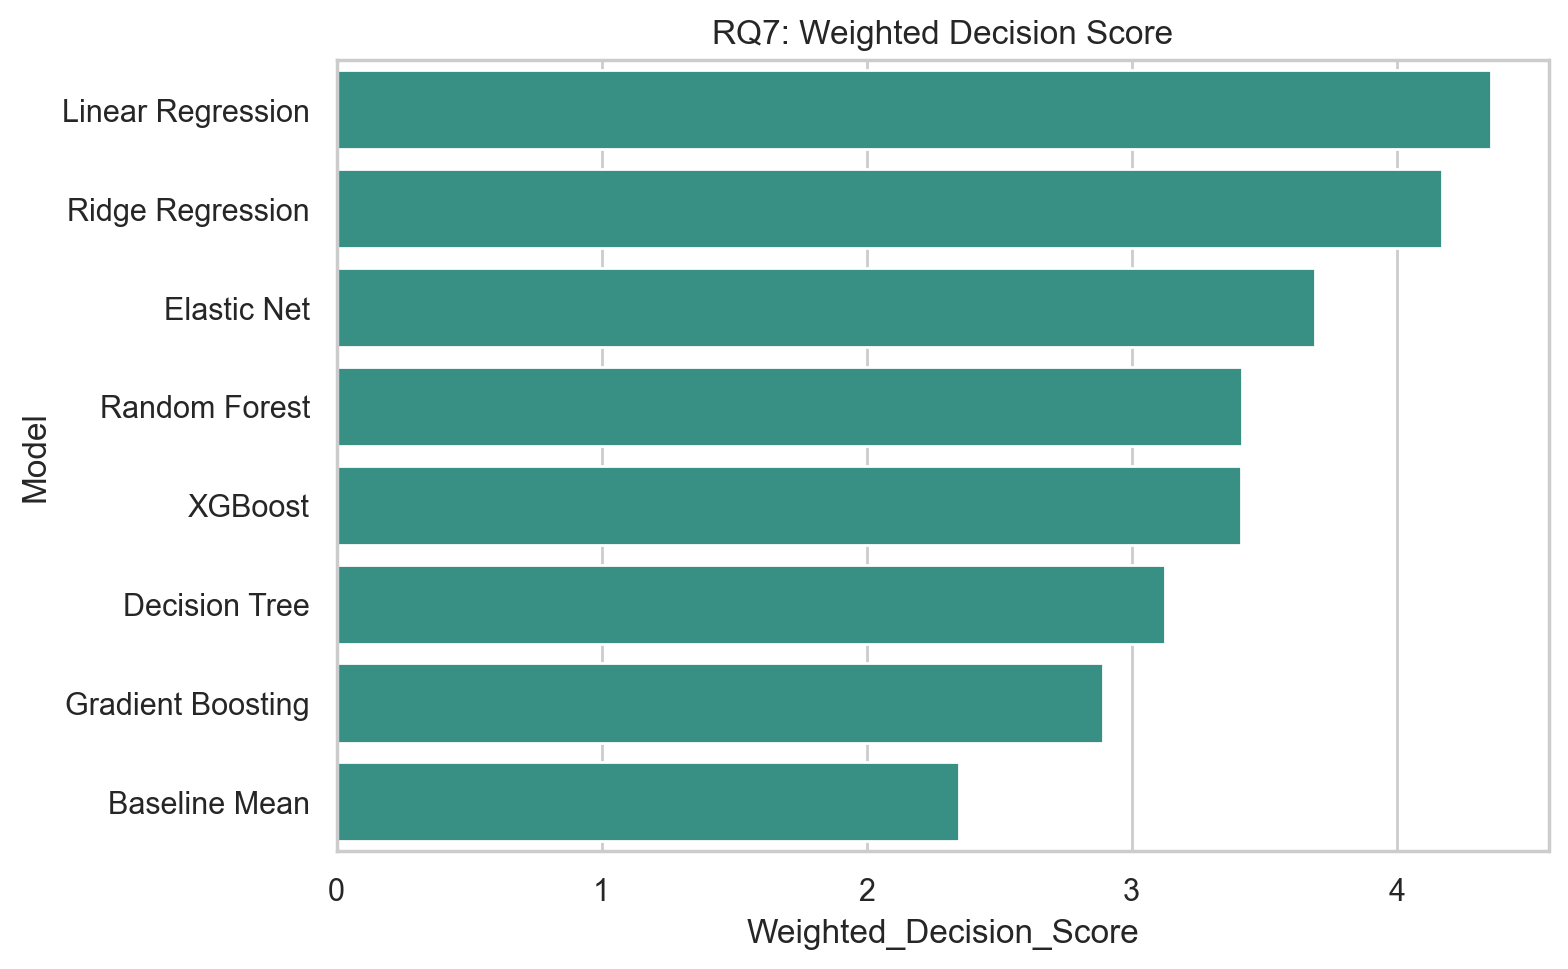

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebook':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from whoop_assignment_pipeline import DATA_PATH

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

print("This notebook displays the executed RQ7 outputs generated by whoop_assignment_pipeline.py.")
print("To regenerate only this RQ, run: from whoop_assignment_pipeline import run_rq7; run_rq7()")

table_path = ROOT / 'outputs' / 'tables' / 'RQ7_decision_matrix.csv'
display(pd.read_csv(table_path).head(15))

for image_name in ['RQ7_decision_matrix_heatmap.png', 'RQ7_weighted_decision_score.png']:
    image_path = ROOT / 'outputs' / 'figures' / 'images' / image_name
    if image_path.exists():
        display(Image(filename=str(image_path)))
